## ``Modern Portfolio Theory - Genetic Algorithm``

##### ``Sandra Ranilla-Cortina``

In [1]:
# Libraries
import numpy as np
import pandas as pd
import random
from datetime import timedelta
import time
from time import process_time
from os import listdir
import warnings
import matplotlib.pyplot as plt

In [2]:
# FUNDS DATA
def fund_load(dir):
    '''
    Returns the data frame composed by the files read in the given directory

    Parameters:
        dir (string): Name of the directory

    Return:
        df_fund (DataFrame): Funds data

    '''

    warnings.filterwarnings("ignore")
    df_fund = pd.DataFrame()
    for i in listdir(dir):
        df_fund = pd.concat([df_fund, pd.read_csv(dir + '/' + str(i), parse_dates = True, index_col = 0)])
    return df_fund

df_fund = fund_load(dir = '../data/data_GeneticAlgorithm/Funds')

In [3]:
# FUNDS HOMOGENIZATION
def fund_homogenization(df_fund):
    '''
    Returns the homogenization of the given data frame (group by fund ISIN as columns, DATE as the index and NAV as values)

    Parameters:
        df_fund (DataFrame): Funds data

    Return:
        df_fund (DataFrame): Homogenized funds data

    '''

    df_fund = pd.pivot_table(data = df_fund, index = ['date'], columns = ['isin'], values = ['nav'])
    df_fund = df_fund.droplevel(0, axis = 1).rename_axis(index = None, columns = None)
    return df_fund

df_fund = fund_homogenization(df_fund = df_fund)

In [4]:
# FUNDS NA ANALYSIS
def fund_na_analysis(df_fund, pna_fund, pna_date):
    '''
    Returns the given homogenized data frame after doing the NA analysis: 
        1) finds and dismisses the funds whose percentage of NA values exceed the given threshold; 
        2) finds and dismisses the dates whose percentage of NA values exceed the given threshold; 
        3) fills the remaining NA values with previous data; 
        4) if not previous data, fills the remaining NA values with first next value;

    Parameters:
        df_fund (DataFrame): Homogenized funds data
        pna_fund (float): NA threshold for funds
        pna_date (float): NA threshold for dates

    Return:
        df_fund (DataFrame): Clean homogenized funds data

    '''

    # NA criteria #1: if NA percentage (by fund) >= pna_fund, dismiss fund
    perc_na_fund = df_fund.isna().sum(axis = 0) / df_fund.shape[0]
    df_fund = df_fund[perc_na_fund[perc_na_fund < pna_fund].index]

    # NA criteria #2: if NA percentage (by date) >= pna_date, dismiss date
    perc_na_date = df_fund.isna().sum(axis = 1) / df_fund.shape[1]
    df_fund = df_fund.loc[perc_na_date[perc_na_date < pna_date].index]

    # NA criteria #3: set remaining NA values with previous data 
    df_fund.fillna(method = 'ffill', inplace = True)

    # NA criteria #4: if not previous data, first next value
    df_fund.fillna(method = 'bfill', inplace = True)

    return df_fund

df_fund = fund_na_analysis(df_fund = df_fund, pna_fund = 0.80, pna_date = 0.90)

In [5]:
# FIRST GENERATION
def first_generation(df_fund, n_investor, n_port):
    '''
    Returns the first generation of portfolio configurations for each investor

    Parameters:
        df_fund (DataFrame): Homogenized funds data
        n_investor (int): Number of investors
        n_port (int): Number of configurations

    Return:
        passet (Array): Configuration assets per investor (shape = (n_investor))
        wasset (Array): Configuration weights per investor (shape = (n_investor x n_port))

    '''

    # Random #1: Random choice of the weights per investor - First configuration
    wasset = []
    for _ in range(n_investor):
        wasset_i = []
        nasset_i = np.random.randint(2, 10)
        limit = 1
        for i in range(nasset_i):
            random_weight = np.random.uniform(0, limit)
            wasset_i.append(random_weight)
            limit = limit - random_weight
        wasset.append(wasset_i)

    # Random #2: Random choice of the N funds (first configuration determines number of assets per investor)
    passet = []
    for i in range(n_investor):
        passet_i = np.random.choice(a = df_fund.columns.to_list(), size = (len(wasset[i])))
        passet_i = [df_fund.columns.get_loc(x) for x in passet_i]
        passet.append(passet_i)

    # Random #3: Random choice of the weights - Rest of configurations (total of 100)
    wasset_loop = []
    for i in range(n_investor):
        wasset_loop_i = [wasset[i]] 
        for _ in range(n_port - 1):
            wasset_x = []
            limit = 1
            for _ in range(len(wasset[i])):
                random_weight = np.random.uniform(0, limit)
                wasset_x.append(random_weight)
                limit = limit - random_weight
            wasset_loop_i.append(wasset_x)
        wasset_loop.append(wasset_loop_i)
    wasset = wasset_loop

    return passet, wasset

In [6]:
# OBJETIVE FUNCTION - SHARPE RATIO
def obj_func_sharpe(df_fund, wasset):
    '''
    Returns the best Sharpe ratio for a given set of funds and configurations

    Parameters:
        df_fund (DataFrame): Funds data of the configuration assets of an investor
        wasset (Array): Configuration weights of an investor (shape = (n_port))

    Return:
        pbe (float): Best Sharpe ratio found among the configurations
        wbe_pos (int): Configuration index of the best Sharpe ratio found

    '''

    # Funds yield
    yield_funds = np.log(df_fund).diff() 
    yield_funds = yield_funds.iloc[1:,:]

    # Variance-Covariance Matrix
    mcov = yield_funds.cov()
    mcov = mcov.to_numpy(dtype = 'float')

    # Daily Yield
    init_price = df_fund.iloc[0,:]
    final_price = df_fund.iloc[-1,:]
    daily_yield = np.log(final_price / init_price) / df_fund.shape[0]

    # Portfolio Yield
    yield_funds = daily_yield.values * wasset
    portfolio_yield = yield_funds.sum(axis = 1) * 252

    # Portfolio Risk
    risk_funds = np.dot(wasset, mcov)
    portfolio_risk = pow((risk_funds * wasset).sum(axis = 1), 0.5) * np.sqrt(252)

    # Portfolio Efficiency
    ports_00 = (portfolio_yield == 0) * (portfolio_risk == 0)
    portfolio_risk[ports_00] = 0.0000001
    portfolio_efficiency = portfolio_yield / portfolio_risk

    # Portfolio Best Efficiency
    pbe = max(portfolio_efficiency)
    pbe_pos = np.where(portfolio_efficiency == pbe)[0][0]
    wbe_pos = wasset[pbe_pos]

    return pbe, wbe_pos

In [7]:
# FUNDS (INDEPENDENT) SHARPE RATIO
def asset_indep_sharpe(df_fund):
    '''
    Returns the independent Sharpe ratio for a given set of funds

    Parameters:
        df_fund (DataFrame): Homogenized funds data

    Return:
        portfolio_efficiency (DataFrame): Sharpe ratio per asset

    '''

    # Funds yield
    yield_funds = np.log(df_fund) - np.log(df_fund.shift(1))
    yield_funds = yield_funds.iloc[1:,:]

    # Portfolio Risk
    portfolio_risk = yield_funds.std(axis = 0)

    # Portfolio Yield
    portfolio_yield = yield_funds.sum(axis = 0)

    # Portfolio Efficiency
    portfolio_efficiency = portfolio_yield / portfolio_risk
    portfolio_efficiency[portfolio_risk == 0] = 0 

    return portfolio_efficiency

In [8]:
# ELITE POPULATION
def elite_population(df_fund, n_investor, passet, wasset):
    '''
    Returns the best Sharpe ratio per investor, its min-max normalization and 
    the corresponding configuration of each best Sharpe ratio portfolio

    Parameters:
        df_fund (DataFrame): Homogenized funds data
        n_investor (int): Number of investors
        passet (Array): Configuration assets per investor (shape = (n_investor))
        wasset (Array): Configuration weights per investor (shape = (n_investor x n_port))

    Return:
        elite_pop_port (Array): Portfolio configuration of best Sharpe ratio per investor
        elite_pop_sharpe (Array): Best Sharpe ratio per investor
        elite_pop_sharpe_norm (Array): Min-max normalization of best Sharpe ratios

    '''

    # Loop
    elite_pop_port = []
    elite_pop_sharpe = []
    for i in range(n_investor):
        # Fitness function - Sharpe ratio
        elite_pop_i = pd.DataFrame(passet[i], columns = ['Fund_ID'])
        pbe, wbe_pos = obj_func_sharpe(df_fund = df_fund.iloc[:, passet[i]], wasset = wasset[i])
        elite_pop_i['Weight'] = wbe_pos
        elite_pop_port.append(elite_pop_i)
        elite_pop_sharpe.append(pbe)

    # Sharpe normalization
    max_sharpe = np.max(elite_pop_sharpe)
    min_sharpe = np.min(elite_pop_sharpe)
    elite_pop_sharpe_norm = (elite_pop_sharpe - min_sharpe)/(max_sharpe - min_sharpe)

    return elite_pop_port, elite_pop_sharpe, elite_pop_sharpe_norm

In [9]:
# ROULETTE SELECTION - FITNESS PROPORTIONATE SELECTION
def fitness_prop_select(n_investor, elite_pop_port, elite_pop_sharpe_norm):
    '''
    Returns the portfolio configuration of chromosome #1 and chromosome #2

    Parameters:
        n_investor (int): Number of investors
        elite_pop_port (Array): Portfolio configuration of best Sharpe ratio per investor
        elite_pop_sharpe_norm (Array): Min-max normalization of best Sharpe ratios

    Return:
        chromosome_1 (DataFrame): Portfolio configuration of chromosome #1
        chromosome_2 (DataFrame): Portfolio configuration of chromosome #2

    '''

    # Chromosome #1: Roulette Selection - Fitness proportionate selection
    fitness_threshold = random.random()
    chromosome_cont = random.randint(0, n_investor - 1)
    chromosome_sharpe = 0
    while chromosome_sharpe < fitness_threshold:
        if (n_investor <= chromosome_cont):
            chromosome_cont = 0
        chromosome_sharpe = elite_pop_sharpe_norm[chromosome_cont]
        chromosome_cont += 1
    chromosome_1 = elite_pop_port[chromosome_cont - 1]

    # Chromosome #2: Roulette Selection - Fitness proportionate selection
    fitness_threshold = random.random()
    chromosome_cont_aux = chromosome_cont
    chromosome_cont = random.randint(0, n_investor - 1 - 1)
    chromosome_sharpe = 0
    while chromosome_sharpe < fitness_threshold:
        if (n_investor - 1 <= chromosome_cont):
            chromosome_cont = 0
        if (chromosome_cont_aux == chromosome_cont):
            pass
        else:
            chromosome_sharpe = elite_pop_sharpe_norm[chromosome_cont]
        chromosome_cont += 1
    chromosome_2 = elite_pop_port[chromosome_cont - 1]

    return chromosome_1, chromosome_2

In [10]:
# MUTATION CHROMOSOME
def mutation_chromosome(df_fund, n_asset, chromosome_1, chromosome_2, weight_threshold, corr_threshold):
    '''
    Returns the portfolio configuration of mutation chromosome from chromosome #1 and chromosome #2

    Parameters:
        df_fund (DataFrame): Homogenized funds data
        n_asset (int): Number of assets threshold
        chromosome_1 (DataFrame): Portfolio configuration of chromosome #1
        chromosome_2 (DataFrame): Portfolio configuration of chromosome #2
        weight_threshold (float): Weight threshold
        corr_threshold (float): Correlation threshold

    Return:
        chromosome_mut (DataFrame): Portfolio configuration of mutation chromosome

    '''

    # Filter #1: Assets whose weight > threshold (in both chromosones)
    chromosome_f1 = np.unique(pd.concat([chromosome_1[chromosome_1.Weight > weight_threshold].Fund_ID, chromosome_2[chromosome_2.Weight > weight_threshold].Fund_ID]))

    # Funds yield
    yield_funds = np.log(df_fund.iloc[:, chromosome_f1]) - np.log(df_fund.iloc[:, chromosome_f1].shift(1))
    yield_funds = yield_funds.iloc[1:,:]

    # Correlation matrix
    mcorr = yield_funds.corr()
    mcorr = mcorr.to_numpy(dtype = 'float')

    # Filter #2: Assets whose correlation < threshold (with rest of assetss)
    chromosome_f2 = []
    for i in range(mcorr.shape[0]):
        row = np.delete(mcorr[i], i)
        max_corr = np.max(row)
        min_corr = abs(np.min(row))
        if (max_corr >= corr_threshold) or (min_corr >= corr_threshold):
            pass
        else:
            chromosome_f2.append(chromosome_f1[i])

    # Filter #3: Asset whose correlation >= threshold (with rest of assetss) and has the best Sharpe ratio
    chromosome_f3 = chromosome_f1.tolist()
    for x in chromosome_f2:
        chromosome_f3.remove(x)
    chromosome_next = chromosome_f2
    if (len(chromosome_f3) > 0):
        sharpe_indep = asset_indep_sharpe(df_fund.iloc[:, chromosome_f3])
        sharpe_indep = sharpe_indep.sort_values(ascending = False).index[0]
        chromosome_next.append(df_fund.columns.get_loc(sharpe_indep))

    # Gen mutation (next generation)
    def gen_mutation(df_fund, chromosome_next):

        # Random #1: Number of assets to be inherited (at least one)
        n_asset_inhe = random.randint(1, 4)
        chromosome_mut = random.choices(chromosome_next, k = n_asset_inhe)

        # Random #2: Funds to make up the mutation (inheritance + mutation)
        funds_mut = np.delete(df_fund.columns.values, chromosome_mut)
        funds_mut = random.choices(funds_mut, k = (n_asset - n_asset_inhe))
        chromosome_mut.extend([df_fund.columns.get_loc(x) for x in funds_mut])

        return chromosome_mut

    chromosome_mut = gen_mutation(df_fund = df_fund, chromosome_next = chromosome_next)

    return chromosome_mut

In [11]:
# NEXT GENERATION
def next_generation(df_fund, next_gen, n_investor, n_port, n_asset, pbe_sharpe_evol, pbe_port_evol):
    '''
    Returns the complete configurations for next generation, the list of best Sharpe ratio found at
    each generation and their portfolio configurations

    Parameters:
        df_fund (DataFrame): Homogenized funds data
        next_gen (Array): Portfolio configurations from previous generation (shape = (n_investor))
        n_investor (int): Number of investors
        n_port (int): Number of configurations
        n_asset (int): Number of assets threshold
        pbe_sharpe_evol (Array): Best Sharpe ratio per generation
        pbe_port_evol (Array): Portfolio configuration of best Sharpe ratio per generation

    Return:
        pbe_sharpe_evol (Array): Best Sharpe ratio per generation
        pbe_port_evol (Array): Portfolio configuration of best Sharpe ratio per generation
        pbe_port_evol (DataFrame): Portfolio configuration of best Sharpe ratio per generation
        next_gen_x (Array): Portfolio configurations for next generation (shape = (n_investor))

    '''

    # Weight allocation
    wasset_loop = []
    for _ in range(n_investor):
        wasset_loop_i = []
        for _ in range(n_port):
            wasset_x = []
            limit = 1
            for _ in range(n_asset):
                random_weight = np.random.uniform(0, limit)
                wasset_x.append(random_weight)
                limit = limit - random_weight
            wasset_loop_i.append(wasset_x)
        wasset_loop.append(wasset_loop_i)

    # Elite population
    elite_pop_port, elite_pop_sharpe, elite_pop_sharpe_norm = elite_population(df_fund = df_fund, n_investor = n_investor, passet = next_gen, wasset = wasset_loop)

    # Portfolio with best Sharpe ratio
    pbe_sharpe_evol.append(np.max(elite_pop_sharpe))
    pbe_pos = np.where(elite_pop_sharpe == pbe_sharpe_evol[-1])[0][0]
    pbe_port_evol.append(elite_pop_port[pbe_pos].Fund_ID.values.tolist())
    pbe_port_evol_df = pd.DataFrame(df_fund.columns[pbe_port_evol[-1]], columns = ['Isin'])
    pbe_port_evol_df['Weight'] = elite_pop_port[pbe_pos].Weight.round(decimals = 4)
    pbe_port_evol_df = pbe_port_evol_df[pbe_port_evol_df.Weight > 0]

    # Next generation
    next_gen_x = []
    
    # Mutation #1:
    # Portfolio with best Sharpe ratio in generation x
    mut_x = pbe_port_evol[-1]
    # Mutation
    funds_comp = np.delete(df_fund.columns.values, mut_x)
    funds_comp = random.choices(funds_comp, k = (n_asset - len(mut_x)))
    mut_x.extend([df_fund.columns.get_loc(x) for x in funds_comp])
    next_gen_x.append(mut_x)

    # Mutation #(Number of investors - 1)
    for _ in range(n_investor - 1):
        # Roulette Selection - Fitness proportionate selection
        chromosome_1, chromosome_2 = fitness_prop_select(n_investor = n_investor, elite_pop_port = elite_pop_port, elite_pop_sharpe_norm = elite_pop_sharpe_norm)
        # Mutation
        gen_x = mutation_chromosome(df_fund = df_fund, n_asset = n_asset, chromosome_1 = chromosome_1, chromosome_2 = chromosome_2, weight_threshold = 0, corr_threshold = 0.5)
        next_gen_x.append(gen_x)

    return pbe_sharpe_evol, pbe_port_evol, pbe_port_evol_df, next_gen_x

In [12]:
######################################################################################################
############################################ FULL PROCESS ############################################
######################################################################################################

# Timer starting
elapsed_time = time.time()
cpu_time = process_time()

############################################ GENERATION 0 ############################################

# Initialization
n_investor = 50
n_port = 100
n_asset = 20
passet, wasset = first_generation(df_fund, n_investor = n_investor, n_port = n_port)
elite_pop_port, elite_pop_sharpe, elite_pop_sharpe_norm = elite_population(df_fund = df_fund,
                n_investor = n_investor, passet = passet, wasset = wasset)

# Portfolio with best Sharpe ratio in generation #0
pbe_sharpe_evol = [np.max(elite_pop_sharpe)]
pbe_pos = np.where(elite_pop_sharpe == pbe_sharpe_evol[0])[0][0]
pbe_port_evol = [elite_pop_port[pbe_pos].Fund_ID.values.tolist()]
pbe_port_evol_df = pd.DataFrame(df_fund.columns[pbe_port_evol[0]], columns = ['Isin'])
pbe_port_evol_df['Weight'] = elite_pop_port[pbe_pos].Weight.round(decimals = 4)
print('############################################')
print(f'Generation #{0}: \n (*) Sharpe ratio: ', pbe_sharpe_evol[0].round(decimals = 4),
      ' \n (*) Portfolio: \n', pbe_port_evol_df)

# Mutation #1
# Portfolio with best Sharpe ratio in generation #0
mut_x = pbe_port_evol[0]
# Mutation
funds_comp = np.delete(df_fund.columns.values, mut_x)
funds_comp = random.choices(funds_comp, k = (n_asset - len(mut_x)))
mut_x.extend([df_fund.columns.get_loc(x) for x in funds_comp])
next_gen = [mut_x]
# Mutation #(Number of investors - 1)
for _ in range(n_investor - 1):
    # Roulette Selection - Fitness proportionate selection
    chromosome_1, chromosome_2 = fitness_prop_select(n_investor = n_investor,
                elite_pop_port = elite_pop_port, elite_pop_sharpe_norm = elite_pop_sharpe_norm)
    # Mutation
    gen_x = mutation_chromosome(df_fund = df_fund, n_asset = n_asset, chromosome_1 = chromosome_1,
                chromosome_2 = chromosome_2, weight_threshold = 0, corr_threshold = 0.5)
    next_gen.append(gen_x)

############################################ GENERATION X ############################################

# Do while: #generation (n_gen) < 100 and number of generations without improvement (n_improv) < 20
n_gen = 1
n_improv = 0
pbe_sharpe = pbe_sharpe_evol[0]
pbe_port = pbe_port_evol[0]
pbe_port_df = pbe_port_evol_df
pbe_gen = n_gen
while (n_gen < 100) and (n_improv < 20):
    # Next generation
    pbe_sharpe_evol, pbe_port_evol, pbe_port_evol_df, next_gen_x = next_generation(df_fund = df_fund,
                next_gen = next_gen, n_investor = n_investor, n_port = n_port, n_asset = n_asset,
                pbe_sharpe_evol = pbe_sharpe_evol, pbe_port_evol = pbe_port_evol)

    # Portfolio with best Sharpe ratio in generation #X
    print('')
    print('############################################')
    print(f'Generation #{n_gen}: \n (*) Sharpe ratio: ', pbe_sharpe_evol[-1].round(decimals = 4), 
      ' \n (*) Portfolio: \n', pbe_port_evol_df)
    print('')

    # Sharpe ratio
    if pbe_sharpe_evol[-1] > pbe_sharpe:
        pbe_sharpe = pbe_sharpe_evol[-1]
        pbe_port = pbe_port_evol[-1]
        pbe_port_df = pbe_port_evol_df
        pbe_gen = n_gen
        n_improv = 0
    else:
        n_improv += 1
    n_gen += 1

# Stopping threhold
if n_improv >= 10:
    n_gen -= 1
    print(f'Genetic Algorithm found the Optimal Portfolio after overcomingthreshold of {n_improv} '
          f'generations without improvement of Sharpe ratio in generation {pbe_gen}.')
if n_gen >= 100:
    n_gen -= 1
    print(f'Genetic Algorithm found the Optimal Portfolio in generation {pbe_gen}.')

# Timer ending
cpu_time = process_time() - cpu_time
elapsed_time = time.time() - elapsed_time
print('Process-CPU time = ' + str(timedelta(seconds = cpu_time)))
print('Elapsed-Real time = ' + str(timedelta(seconds = elapsed_time)))

############################################
Generation #0: 
 (*) Sharpe ratio:  4.5786  
 (*) Portfolio: 
            Isin  Weight
0  GB00BH57BR88  0.0037
1  LU2002383540  0.3051

############################################
Generation #1: 
 (*) Sharpe ratio:  5.0678  
 (*) Portfolio: 
            Isin  Weight
0  LU2002383540  0.3025
1  LU2002383540  0.5633
2  GB00BH57BR88  0.0020
3  LU1832969650  0.0126
4  IE00B1S74W91  0.0337
5  LU2049585727  0.0742
6  LU0650148231  0.0087
7  LU1662752887  0.0012
8  LU0134914885  0.0018


############################################
Generation #2: 
 (*) Sharpe ratio:  4.9317  
 (*) Portfolio: 
            Isin  Weight
0  LU2002383540  0.7751
1  LU2002383540  0.1487
2  LU0428706179  0.0729
3  IE00BYZ0BC16  0.0014
4  GB00B3KKY971  0.0002
5  LU1559925901  0.0014
6  LU2008561719  0.0001
7  LU1295556705  0.0001


############################################
Generation #3: 
 (*) Sharpe ratio:  4.9244  
 (*) Portfolio: 
            Isin  Weight
0  LU200238

GENETIC ALGORITHM - OPTIMAL PORTFOLIO
Generation #8: 
 (*) Sharpe ratio:  5.3189  
 (*) Portfolio: 
            Isin  Weight
0  LU2002383540  0.0288
1  LU2002383540  0.7564
2  GB00BH57BR88  0.0011
3  LU1832969650  0.0076
4  IE00B1S74W91  0.0324
5  LU2049585727  0.1708
6  LU0650148231  0.0025
7  LU1662752887  0.0002
8  LU0134914885  0.0001


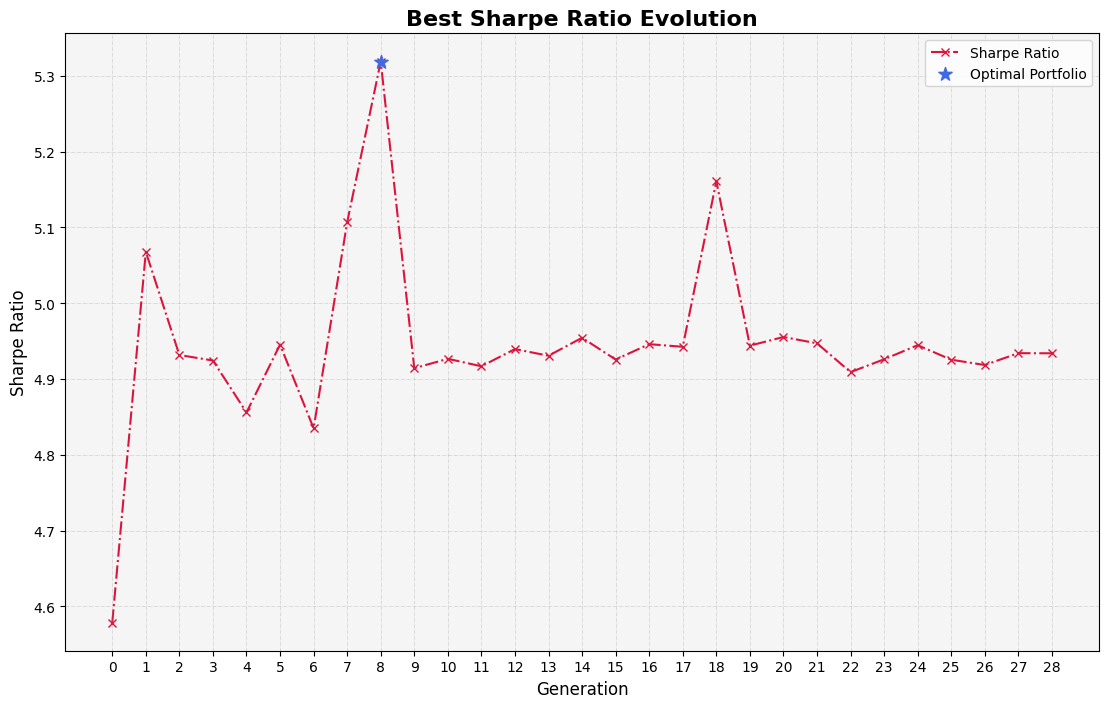

In [ ]:
# GENETIC ALGORITHM - OPTIMAL PORTFOLIO
print(f'GENETIC ALGORITHM - OPTIMAL PORTFOLIO')
print(f'Generation #{pbe_gen}: \n (*) Sharpe ratio: ', pbe_sharpe.round(decimals = 4),
      ' \n (*) Portfolio: \n', pbe_port_df)
fig, ax = plt.subplots(1, figsize = (12, 8))
ax.plot(pbe_sharpe_evol, label = 'Sharpe Ratio', color = 'crimson', marker = 'x', linestyle = '-.', zorder = 1)
ax.scatter([pbe_gen], [pbe_sharpe], label = 'Optimal Portfolio', color = 'royalblue', marker = '*', s = 102, zorder = 2)
ax.set_facecolor('whitesmoke')
plt.xticks(range(n_gen + 1), np.arange(0, n_gen + 1))
plt.title(label = 'Best Sharpe Ratio Evolution', fontsize = 16, fontweight = 'bold')
plt.xlabel('Generation', fontsize = 12)
plt.ylabel('Sharpe Ratio', fontsize = 12)
plt.grid(visible = True, color = 'grey', linestyle = '-.', linewidth = 0.4, alpha = 0.4)
plt.tight_layout(pad = 4.0)
plt.legend(fontsize = 10)
#fig.savefig('../res/GeneticAlgorithmOptimalPortfolio.jpg')
plt.show()